### 2. Un condensateur électronique

#### 2.a) méthode de Gauss-Seidel avec relaxation

omega = 0.92, temps = 2.4297809000127017


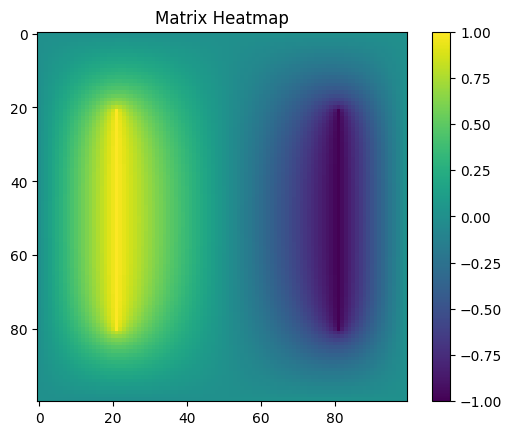

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()
condo = np.zeros((100, 100), float)
dcondo = np.zeros((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1
omega = 0.92

delta = 1
target = 10e-6
while delta > target:
    for i in range(100):
        for j in range (100):
            if i == 0 or i == 99 or j == 0 or j == 99:
                pass
            elif (j == 21 or j == 81) and (i >= 21 and i <= 80):
                pass
            else:
                dcondo[i,j] = (1+omega)*((condo[i,j+1] + condo[i,j-1] + condo[i+1,j] + condo[i-1,j])/4 - condo[i,j])
                condo[i,j] += dcondo[i,j]

    delta = np.max(np.abs(dcondo))

print(f"omega = {omega}, temps = {time.perf_counter()-start}")
temps.append(time.perf_counter()-start)
omeg.append(omega)


plt.imshow(condo)
plt.colorbar()
plt.title("Matrix Heatmap")
plt.show()

#### 2.b) Effet du paramètre omega sur le temps de traitement de la méthode de Gauss-Seidel

On remarque qu'en utilisant une valeur d'omega trop faible la méthode de Gauss-Seidel prend beaucoup de temps pour converger vers une réponse. En utilisant une valeur trop grande la résolution devient instable et aucune solution n'est trouvé. Dans notre cas, un omega de 0.92 permet de résouder le problème le plus rapidement avec un temps de calcul d'environ 4.6 secondes.

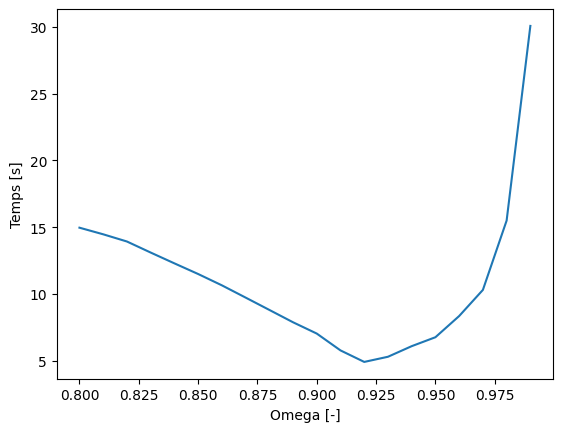

In [61]:
omeg = [0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.8400000000000001, 0.8500000000000001, 0.8600000000000001, 0.8700000000000001, 0.8800000000000001, 0.8900000000000001, 0.9000000000000001, 0.9100000000000001, 0.9200000000000002, 0.9300000000000002, 0.9400000000000002, 0.9500000000000002, 0.9600000000000002, 0.9700000000000002, 0.9800000000000002, 0.9900000000000002]
temps = [14.961928300006548, 14.46697330000461, 13.927888399979565, 13.101793799985899, 12.292735800001537, 11.49598700000206, 10.648866300005466, 9.731841300002998, 8.808545300009428, 7.8830707000161055, 7.037128700001631, 5.776960699993651, 4.915481299976818, 5.3019012000004295, 6.0947386999905575, 6.763952499983134, 8.350215299986303, 10.30569489998743, 15.494322400016245, 30.06184249999933]
plt.plot(omeg, temps)
plt.xlabel("Omega [-]")
plt.ylabel("Temps [s]")
plt.show()

#### 2.c) Méthode de Jacobi 

temps = 12.939523199980613


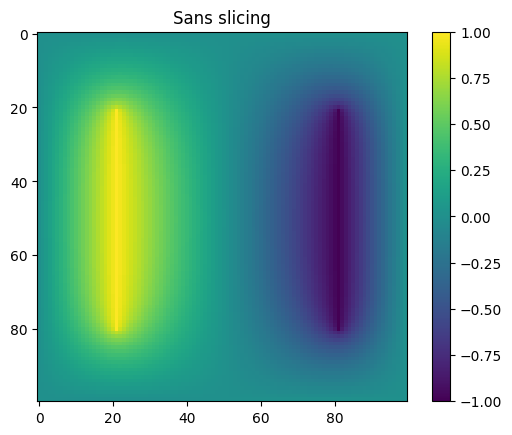

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()

condo = np.zeros((100, 100), float)
condo_prime = np.empty((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1



delta = 1
target = 10e-6

while delta > target:
    for i in range(100):
        for j in range (100):
            if i == 0 or i == 99 or j == 0 or j == 99:
                condo_prime[i,j] = condo[i,j]
            elif (j == 21 or j == 81) and (i >= 21 and i <= 80):
                condo_prime[i,j] = condo[i,j]
            else:
                condo_prime[i,j] = (condo[i,j+1] + condo[i,j-1] + condo[i+1,j] + condo[i-1,j])/4

    delta = np.max(np.abs(condo - condo_prime))
    condo_prime, condo = condo, condo_prime

print(f"temps = {time.perf_counter()-start}")

plt.imshow(condo)
plt.colorbar()
plt.title("Sans slicing")
plt.show()


temps = 0.07320230000186712


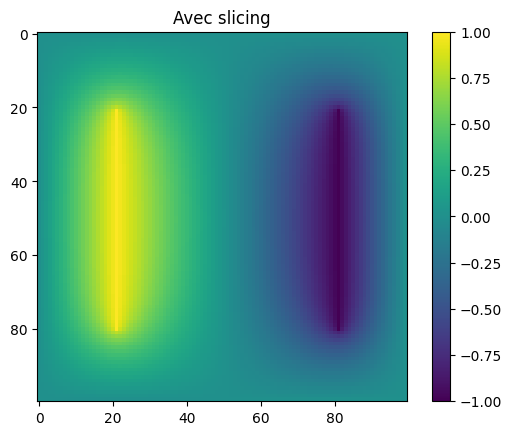

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

start = time.perf_counter()

condo = np.zeros((100, 100), float)
condo_prime = np.empty((100, 100), float)
condo[21:81, 21] = 1
condo[21:81, 81] = -1



delta = 1
target = 10e-6

while delta > target:


    condo_prime[1:-1, 1:-1] = 0.25 * (
        condo[1:-1, 2:] +    
        condo[1:-1, :-2] +   
        condo[2:, 1:-1] +    
        condo[:-2, 1:-1])    

    condo_prime[0, :]  = condo[0, :]
    condo_prime[-1, :] = condo[-1, :]
    condo_prime[:, 0]  = condo[:, 0]
    condo_prime[:, -1] = condo[:, -1]

    condo_prime[21:81, 21] = condo[21:81, 21]
    condo_prime[21:81, 81] = condo[21:81, 81]

    delta = np.max(np.abs(condo - condo_prime))

    condo, condo_prime = condo_prime, condo

print(f"temps = {time.perf_counter()-start}")

plt.imshow(condo)
plt.colorbar()
plt.title("Avec slicing")
plt.show()

En comparant les trois méthodes, on remarques que la méthode la plus rapide pour une grille de 100x100 est celle de Jacobi avec slicing avec un temps de 0.073 secondes. La seconde plus rapide est celle de Gauss-Seidel avec un temps de 4.6 secondes. Finalement, la moins rapide des méthodes est celle de Jacobi sans slicing avec un temps de 12.9 secondes. On peut aussi conclure que la méthode qui serait la plus efficace pour effectuer cette tâche serait celle de Gauss-Seidel avec slicing.